# Updated Emotional Intelligence Analysis System

**Enhanced Features:**
- Class-based profiling instead of individual student analysis
- Visual data representation with charts and graphs
- Top 100 most recent classes analysis
- Progress tracking for long operations
- Clean, efficient code structure

**Data Source:** studentCheckIn_cleaned.csv (pre-cleaned dataset)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
import json
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Try to import tqdm for progress bars
try:
    from tqdm import tqdm
    tqdm_available = True
except ImportError:
    tqdm_available = False
    def tqdm(iterable, desc="Processing"):
        print(f"{desc}...")
        return iterable

warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully")


Libraries imported successfully


## Load and Prepare Data


Loading datasets...
Student check-ins: (757112, 10)
Classes: (583, 3)
Sessions: (31149, 3)
Students: (12467, 7)
Teacher-Class: (3754, 2)


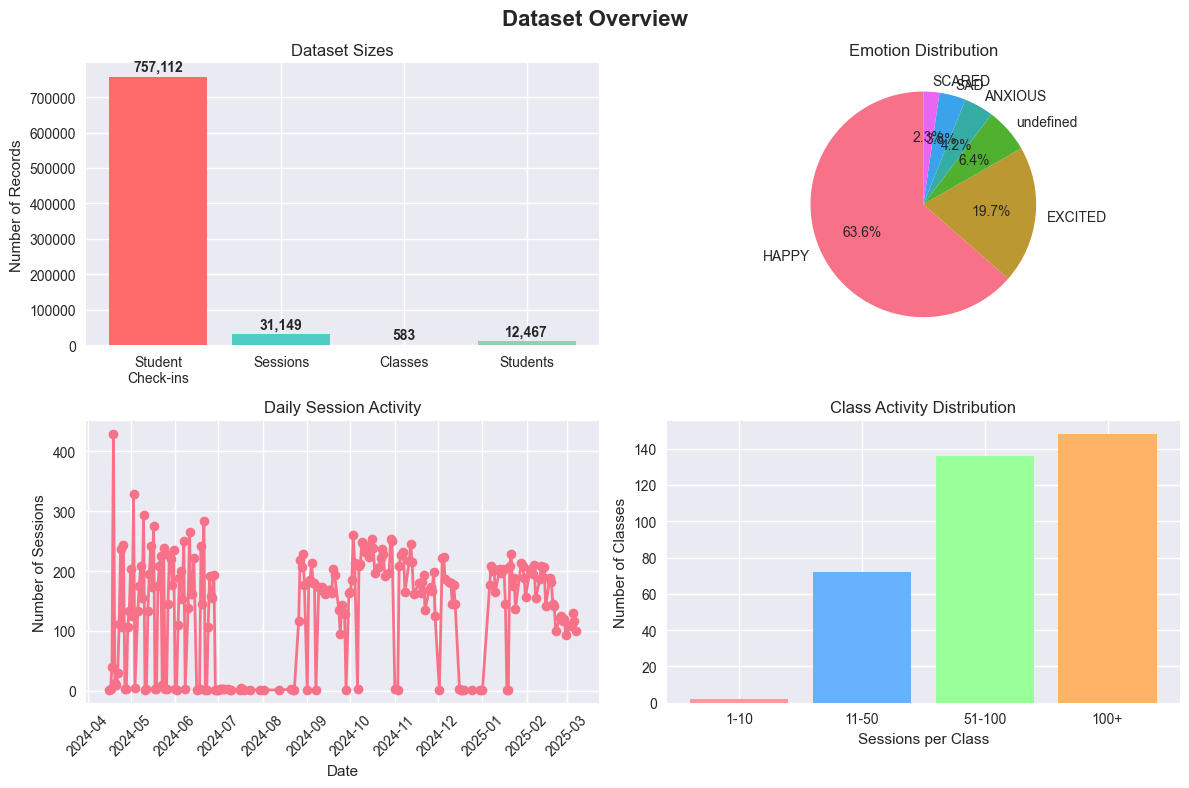

Data loading completed successfully


In [2]:
# Load all required datasets
print("Loading datasets...")

# Load cleaned student check-ins
df_student_checkins = pd.read_csv('datasets/studentCheckIn_cleaned.csv')
print(f"Student check-ins: {df_student_checkins.shape}")

# Load other datasets
df_classes = pd.read_csv('datasets/class.csv')
df_sessions = pd.read_csv('datasets/checkInSession.csv')
df_students = pd.read_csv('datasets/students.csv')
df_teacher_class = pd.read_csv('datasets/teacherClass.csv')

print(f"Classes: {df_classes.shape}")
print(f"Sessions: {df_sessions.shape}")
print(f"Students: {df_students.shape}")
print(f"Teacher-Class: {df_teacher_class.shape}")

# Display basic dataset info
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Dataset Overview', fontsize=16, fontweight='bold')

# Dataset sizes visualization
dataset_sizes = [
    len(df_student_checkins),
    len(df_sessions), 
    len(df_classes),
    len(df_students)
]
dataset_names = ['Student\nCheck-ins', 'Sessions', 'Classes', 'Students']

bars = axes[0,0].bar(dataset_names, dataset_sizes, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
axes[0,0].set_title('Dataset Sizes')
axes[0,0].set_ylabel('Number of Records')
for bar, size in zip(bars, dataset_sizes):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(dataset_sizes)*0.01,
                   f'{size:,}', ha='center', va='bottom', fontweight='bold')

# Emotion distribution
emotion_counts = df_student_checkins['Emotion'].value_counts().head(6)
axes[0,1].pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%', startangle=90)
axes[0,1].set_title('Emotion Distribution')

# Session activity over time
df_sessions['Opened Date Time'] = pd.to_datetime(df_sessions['Opened Date Time'])
daily_sessions = df_sessions.groupby(df_sessions['Opened Date Time'].dt.date).size()
axes[1,0].plot(daily_sessions.index, daily_sessions.values, marker='o', linewidth=2)
axes[1,0].set_title('Daily Session Activity')
axes[1,0].set_xlabel('Date')
axes[1,0].set_ylabel('Number of Sessions')
axes[1,0].tick_params(axis='x', rotation=45)

# Class activity levels
class_activity = df_sessions.groupby('Class ID').size()
activity_ranges = ['1-10', '11-50', '51-100', '100+']
activity_counts = [
    len(class_activity[(class_activity >= 1) & (class_activity <= 10)]),
    len(class_activity[(class_activity >= 11) & (class_activity <= 50)]),
    len(class_activity[(class_activity >= 51) & (class_activity <= 100)]),
    len(class_activity[class_activity > 100])
]
axes[1,1].bar(activity_ranges, activity_counts, color=['#FF9999', '#66B2FF', '#99FF99', '#FFB366'])
axes[1,1].set_title('Class Activity Distribution')
axes[1,1].set_xlabel('Sessions per Class')
axes[1,1].set_ylabel('Number of Classes')

plt.tight_layout()
plt.show()

print("Data loading completed successfully")


## Build Class-Session-Student Relationships


Building class-session-student relationships...
Complete relationship dataset: (757112, 21)
Columns: ['Class ID', 'Check In Session ID', 'Opened Date Time', 'Class Name', 'Class Group ID', 'Student Check In ID', 'Student ID', 'Absencce', 'Emotion', 'Emotion Intensity Percentage', 'Tiredness', 'Request For Chat', 'Chat Cleared', 'Eating', 'ID', 'Nickname', 'Cognito Username', 'SchoolStudent ID', 'First Name', 'Last Name', 'Email']


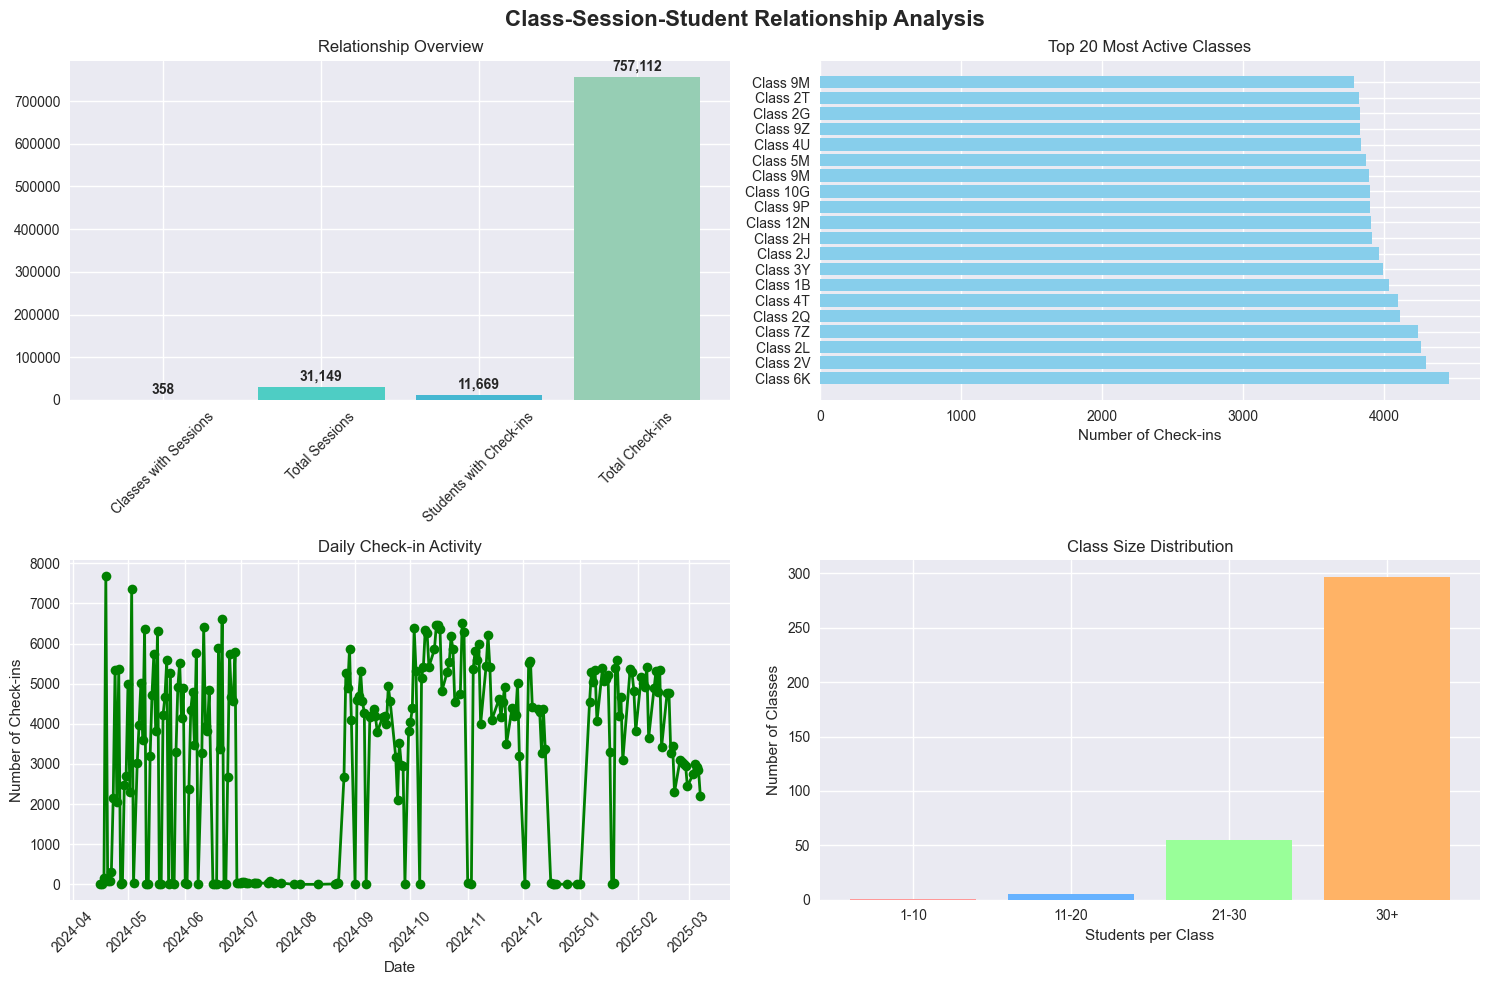

Relationship building completed successfully


In [3]:
# Build comprehensive relationships between classes, sessions, and students
print("Building class-session-student relationships...")

# Merge datasets to create complete relationship
complete_relationship = (
    df_sessions
    .merge(df_classes, on='Class ID', how='left')
    .merge(df_student_checkins, on='Check In Session ID', how='inner')
    .merge(df_students, left_on='Student ID', right_on='ID', how='left')
)

# Convert datetime column
complete_relationship['Opened Date Time'] = pd.to_datetime(complete_relationship['Opened Date Time'])

print(f"Complete relationship dataset: {complete_relationship.shape}")
print(f"Columns: {list(complete_relationship.columns)}")

# Create relationship summary visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Class-Session-Student Relationship Analysis', fontsize=16, fontweight='bold')

# Relationship summary
relationship_summary = {
    'Classes with Sessions': len(complete_relationship['Class ID'].unique()),
    'Total Sessions': len(complete_relationship['Check In Session ID'].unique()),
    'Students with Check-ins': len(complete_relationship['Student ID'].unique()),
    'Total Check-ins': len(complete_relationship)
}

bars = axes[0,0].bar(relationship_summary.keys(), relationship_summary.values(), 
                     color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
axes[0,0].set_title('Relationship Overview')
axes[0,0].tick_params(axis='x', rotation=45)
for bar, value in zip(bars, relationship_summary.values()):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(relationship_summary.values())*0.01,
                   f'{value:,}', ha='center', va='bottom', fontweight='bold')

# Top 20 most active classes
top_classes = complete_relationship.groupby(['Class ID', 'Class Name']).size().sort_values(ascending=False).head(20)
axes[0,1].barh(range(len(top_classes)), top_classes.values, color='skyblue')
axes[0,1].set_yticks(range(len(top_classes)))
axes[0,1].set_yticklabels([name[:15] + '...' if len(name) > 15 else name for name in top_classes.index.get_level_values('Class Name')])
axes[0,1].set_title('Top 20 Most Active Classes')
axes[0,1].set_xlabel('Number of Check-ins')

# Daily activity pattern
daily_activity = complete_relationship.groupby(complete_relationship['Opened Date Time'].dt.date).size()
axes[1,0].plot(daily_activity.index, daily_activity.values, marker='o', linewidth=2, color='green')
axes[1,0].set_title('Daily Check-in Activity')
axes[1,0].set_xlabel('Date')
axes[1,0].set_ylabel('Number of Check-ins')
axes[1,0].tick_params(axis='x', rotation=45)

# Class size distribution
class_sizes = complete_relationship.groupby('Class ID')['Student ID'].nunique()
size_ranges = ['1-10', '11-20', '21-30', '30+']
size_counts = [
    len(class_sizes[(class_sizes >= 1) & (class_sizes <= 10)]),
    len(class_sizes[(class_sizes >= 11) & (class_sizes <= 20)]),
    len(class_sizes[(class_sizes >= 21) & (class_sizes <= 30)]),
    len(class_sizes[class_sizes > 30])
]
axes[1,1].bar(size_ranges, size_counts, color=['#FF9999', '#66B2FF', '#99FF99', '#FFB366'])
axes[1,1].set_title('Class Size Distribution')
axes[1,1].set_xlabel('Students per Class')
axes[1,1].set_ylabel('Number of Classes')

plt.tight_layout()
plt.show()

print("Relationship building completed successfully")


## Identify Top 100 Most Recent Classes


In [ ]:
# Get ALL classes that have any sessions
print("Identifying all classes with sessions...")

# Get all classes with sessions (not limited to most recent date)
all_classes = complete_relationship.groupby(['Class ID', 'Class Name']).agg({
    'Check In Session ID': 'nunique',
    'Student ID': 'nunique',
    'Opened Date Time': 'max'
}).reset_index()

all_classes.columns = ['Class ID', 'Class Name', 'Sessions_Count', 'Students_Count', 'Last_Session']
all_classes = all_classes.sort_values('Sessions_Count', ascending=False)

# Use ALL classes (no cap)
top_100_classes = all_classes
print(f"Found {len(top_100_classes)} classes with sessions")

# Visualize all classes analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('All Classes Analysis', fontsize=16, fontweight='bold')

# Sessions distribution
axes[0,0].hist(top_100_classes['Sessions_Count'], bins=20, color='skyblue', alpha=0.7, edgecolor='black')
axes[0,0].set_title('Sessions Distribution (All Classes)')
axes[0,0].set_xlabel('Number of Sessions')
axes[0,0].set_ylabel('Number of Classes')

# Students distribution
axes[0,1].hist(top_100_classes['Students_Count'], bins=20, color='lightgreen', alpha=0.7, edgecolor='black')
axes[0,1].set_title('Students Distribution (All Classes)')
axes[0,1].set_xlabel('Number of Students')
axes[0,1].set_ylabel('Number of Classes')

# Top 20 classes by session count
top_20_by_sessions = top_100_classes.head(20)
axes[1,0].barh(range(len(top_20_by_sessions)), top_20_by_sessions['Sessions_Count'], color='orange')
axes[1,0].set_yticks(range(len(top_20_by_sessions)))
axes[1,0].set_yticklabels([name[:20] + '...' if len(name) > 20 else name for name in top_20_by_sessions['Class Name']])
axes[1,0].set_title('Top 20 Classes by Session Count')
axes[1,0].set_xlabel('Number of Sessions')

# Correlation between sessions and students
axes[1,1].scatter(top_100_classes['Sessions_Count'], top_100_classes['Students_Count'], alpha=0.6, color='red')
axes[1,1].set_title('Sessions vs Students Correlation')
axes[1,1].set_xlabel('Number of Sessions')
axes[1,1].set_ylabel('Number of Students')

if len(top_100_classes) > 1:
    z = np.polyfit(top_100_classes['Sessions_Count'], top_100_classes['Students_Count'], 1)
    p = np.poly1d(z)
    axes[1,1].plot(top_100_classes['Sessions_Count'], p(top_100_classes['Sessions_Count']), "r--", alpha=0.8)

plt.tight_layout()
plt.show()

print(f"\nAll Classes Summary:")
print(f"Total sessions: {top_100_classes['Sessions_Count'].sum()}")
print(f"Total students: {top_100_classes['Students_Count'].sum()}")
print(f"Average sessions per class: {top_100_classes['Sessions_Count'].mean():.2f}")
print(f"Average students per class: {top_100_classes['Students_Count'].mean():.2f}")

print("All classes identification completed successfully")


## Create Class-Based Emotional Profiles


In [5]:
# Create comprehensive class-based emotional profiles
print("Creating class-based emotional profiles...")

def create_class_profile(class_id, class_data):
    """Create a comprehensive emotional profile for a class"""
    
    # Basic class information
    class_name = class_data['Class Name'].iloc[0]
    total_sessions = class_data['Check In Session ID'].nunique()
    total_students = class_data['Student ID'].nunique()
    last_session = class_data['Opened Date Time'].max()
    
    # Clean emotion data (remove undefined values)
    valid_emotions = class_data[class_data['Emotion'] != 'undefined']
    valid_intensity = valid_emotions[valid_emotions['Emotion Intensity Percentage'] != 'undefined']
    valid_tiredness = class_data[class_data['Tiredness'] != 'undefined']
    
    # Emotion analysis
    if len(valid_emotions) > 0:
        emotion_counts = valid_emotions['Emotion'].value_counts()
        dominant_emotion = emotion_counts.index[0]
        emotion_distribution = emotion_counts.to_dict()
        
        # Calculate average intensity
        if len(valid_intensity) > 0:
            avg_intensity = pd.to_numeric(valid_intensity['Emotion Intensity Percentage'], errors='coerce').mean()
        else:
            avg_intensity = 0.0
            
        # Get recent emotions (last 10 sessions)
        recent_emotions = valid_emotions.sort_values('Opened Date Time').tail(10)['Emotion'].tolist()
    else:
        dominant_emotion = "UNKNOWN"
        emotion_distribution = {}
        avg_intensity = 0.0
        recent_emotions = []
    
    # Wellness indicators
    if len(valid_tiredness) > 0:
        avg_tiredness = pd.to_numeric(valid_tiredness['Tiredness'], errors='coerce').mean()
    else:
        avg_tiredness = 0.0
    
    # Chat requests
    chat_requests = len(class_data[class_data['Request For Chat'] == 'TRUE'])
    
    # Absence rate
    total_check_ins = len(class_data)
    absences = len(class_data[class_data['Absencce'] == 'TRUE'])
    absence_rate = absences / total_check_ins if total_check_ins > 0 else 0.0
    
    # Trend analysis
    if len(valid_intensity) > 5:  # Need enough data for trend analysis
        # Split data into recent and earlier periods
        mid_point = len(valid_intensity) // 2
        recent_data = valid_intensity.tail(mid_point)
        earlier_data = valid_intensity.head(mid_point)
        
        recent_avg_intensity = pd.to_numeric(recent_data['Emotion Intensity Percentage'], errors='coerce').mean()
        earlier_avg_intensity = pd.to_numeric(earlier_data['Emotion Intensity Percentage'], errors='coerce').mean()
        
        # Calculate volatility (standard deviation)
        all_intensities = pd.to_numeric(valid_intensity['Emotion Intensity Percentage'], errors='coerce')
        volatility = all_intensities.std()
        
        # Determine trend
        if recent_avg_intensity > earlier_avg_intensity * 1.05:
            trend = "improving"
        elif recent_avg_intensity < earlier_avg_intensity * 0.95:
            trend = "declining"
        else:
            trend = "stable"
    else:
        recent_avg_intensity = avg_intensity
        earlier_avg_intensity = avg_intensity
        volatility = 0.0
        trend = "insufficient_data"
    
    return {
        "class_id": class_id,
        "class_name": class_name,
        "total_sessions": int(total_sessions),
        "total_students": int(total_students),
        "emotions": {
            "dominant_emotion": dominant_emotion,
            "avg_intensity": round(avg_intensity, 3),
            "emotion_distribution": emotion_distribution,
            "recent_emotions": recent_emotions
        },
        "wellness_indicators": {
            "avg_tiredness": round(avg_tiredness, 2),
            "chat_requests": int(chat_requests),
            "absence_rate": round(absence_rate, 3)
        },
        "trend_analysis": {
            "trend": trend,
            "recent_avg_intensity": round(recent_avg_intensity, 3),
            "earlier_avg_intensity": round(earlier_avg_intensity, 3),
            "volatility": round(volatility, 3)
        },
        "last_session": last_session.isoformat() if pd.notna(last_session) else None
    }

# Process top 100 classes with progress tracking
class_profiles = {}
print(f"Processing {len(top_100_classes)} classes...")

for idx, row in tqdm(top_100_classes.iterrows(), total=len(top_100_classes), desc="Creating class profiles"):
    class_id = row['Class ID']
    class_data = complete_relationship[complete_relationship['Class ID'] == class_id]
    profile = create_class_profile(class_id, class_data)
    class_profiles[class_id] = profile

print(f"Created profiles for {len(class_profiles)} classes")




Creating class-based emotional profiles...
Processing 97 classes...


Creating class profiles: 100%|██████████| 97/97 [00:06<00:00, 16.03it/s]

Created profiles for 97 classes


## Visualize Class Emotional Profiles


In [ ]:
# Create comprehensive visualizations of class emotional profiles
print("Creating visualizations for class emotional profiles...")

# Extract data for visualization
dominant_emotions = [profile['emotions']['dominant_emotion'] for profile in class_profiles.values()]
avg_intensities = [profile['emotions']['avg_intensity'] for profile in class_profiles.values()]
avg_tiredness = [profile['wellness_indicators']['avg_tiredness'] for profile in class_profiles.values()]
trends = [profile['trend_analysis']['trend'] for profile in class_profiles.values()]
session_counts = [profile['total_sessions'] for profile in class_profiles.values()]
student_counts = [profile['total_students'] for profile in class_profiles.values()]

# Create comprehensive visualization dashboard
fig = plt.figure(figsize=(20, 15))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)
fig.suptitle('Class Emotional Profiles Analysis Dashboard', fontsize=20, fontweight='bold', y=0.98)

# 1. Dominant emotions distribution
ax1 = fig.add_subplot(gs[0, 0])
emotion_counts = pd.Series(dominant_emotions).value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(emotion_counts)))
wedges, texts, autotexts = ax1.pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%',
                                   colors=colors, startangle=90)
ax1.set_title('Dominant Emotions Distribution', fontweight='bold', fontsize=12)

# 2. Average emotional intensity distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(avg_intensities, bins=20, color='skyblue', alpha=0.7, edgecolor='black')
ax2.set_title('Average Emotional Intensity Distribution', fontweight='bold', fontsize=12)
ax2.set_xlabel('Average Intensity')
ax2.set_ylabel('Number of Classes')
ax2.axvline(np.mean(avg_intensities), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(avg_intensities):.3f}')
ax2.legend()

# 3. Average tiredness distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(avg_tiredness, bins=15, color='lightcoral', alpha=0.7, edgecolor='black')
ax3.set_title('Average Tiredness Distribution', fontweight='bold', fontsize=12)
ax3.set_xlabel('Average Tiredness Level')
ax3.set_ylabel('Number of Classes')
ax3.axvline(np.mean(avg_tiredness), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(avg_tiredness):.2f}')
ax3.legend()

# 4. Trend analysis
ax4 = fig.add_subplot(gs[0, 3])
trend_counts = pd.Series(trends).value_counts()
bars = ax4.bar(trend_counts.index, trend_counts.values, color=['green', 'orange', 'red', 'gray'])
ax4.set_title('Emotional Trend Analysis', fontweight='bold', fontsize=12)
ax4.set_ylabel('Number of Classes')
for bar, count in zip(bars, trend_counts.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(count),
             ha='center', va='bottom', fontweight='bold')

# 5. Intensity vs Tiredness scatter plot
ax5 = fig.add_subplot(gs[1, 0])
scatter = ax5.scatter(avg_intensities, avg_tiredness, alpha=0.6, c=session_counts, cmap='viridis', s=50)
ax5.set_title('Emotional Intensity vs Tiredness', fontweight='bold', fontsize=12)
ax5.set_xlabel('Average Emotional Intensity')
ax5.set_ylabel('Average Tiredness Level')
cbar = plt.colorbar(scatter, ax=ax5)
cbar.set_label('Number of Sessions')

# 6. Top 15 classes by emotional intensity
ax6 = fig.add_subplot(gs[1, 1])
top_intensity_classes = sorted(zip([profile['class_name'] for profile in class_profiles.values()], avg_intensities),
                               key=lambda x: x[1], reverse=True)[:15]
class_names, intensities = zip(*top_intensity_classes)
bars = ax6.barh(range(len(class_names)), intensities, color='lightgreen')
ax6.set_yticks(range(len(class_names)))
ax6.set_yticklabels([name[:20] + '...' if len(name) > 20 else name for name in class_names])
ax6.set_title('Top 15 Classes by Emotional Intensity', fontweight='bold', fontsize=12)
ax6.set_xlabel('Average Intensity')

# 7. Class size vs emotional intensity (fixed: use z_students variable)
ax7 = fig.add_subplot(gs[1, 2])
z_students = np.polyfit(student_counts, avg_intensities, 1)
p_students = np.poly1d(z_students)
ax7.scatter(student_counts, avg_intensities, alpha=0.6, color='purple')
ax7.plot(student_counts, p_students(student_counts), "r--", alpha=0.8)
ax7.set_title('Class Size vs Emotional Intensity', fontweight='bold', fontsize=12)
ax7.set_xlabel('Number of Students')
ax7.set_ylabel('Average Emotional Intensity')

# 8. Sessions vs Students correlation
ax8 = fig.add_subplot(gs[1, 3])
z = np.polyfit(session_counts, student_counts, 1)
p = np.poly1d(z)
ax8.scatter(session_counts, student_counts, alpha=0.6, color='orange')
ax8.plot(session_counts, p(session_counts), "r--", alpha=0.8)
ax8.set_title('Sessions vs Students Correlation', fontweight='bold', fontsize=12)
ax8.set_xlabel('Number of Sessions')
ax8.set_ylabel('Number of Students')

# 9. Emotion distribution heatmap (top emotions)
ax9 = fig.add_subplot(gs[2, :2])
emotion_matrix = []
class_names_for_heatmap = []
top_emotions = ['HAPPY', 'EXCITED', 'SAD', 'ANXIOUS', 'SCARED', 'ANGRY']

for profile in list(class_profiles.values())[:20]:  # Top 20 classes
    class_names_for_heatmap.append(profile['class_name'][:15])
    emotion_row = []
    for emotion in top_emotions:
        count = profile['emotions']['emotion_distribution'].get(emotion, 0)
        emotion_row.append(count)
    emotion_matrix.append(emotion_row)

emotion_matrix = np.array(emotion_matrix)
im = ax9.imshow(emotion_matrix.T, cmap='YlOrRd', aspect='auto')
ax9.set_xticks(range(len(class_names_for_heatmap)))
ax9.set_xticklabels(class_names_for_heatmap, rotation=45, ha='right')
ax9.set_yticks(range(len(top_emotions)))
ax9.set_yticklabels(top_emotions)
ax9.set_title('Emotion Distribution Heatmap (Top 20 Classes)', fontweight='bold', fontsize=12)
cbar = plt.colorbar(im, ax=ax9)
cbar.set_label('Emotion Count')

# 10. Summary statistics
ax10 = fig.add_subplot(gs[2, 2:])
ax10.axis('off')
summary_text = f"""
CLASS EMOTIONAL PROFILES SUMMARY

Total Classes Analyzed: {len(class_profiles)}

EMOTIONAL INSIGHTS:
• Most Common Dominant Emotion: {pd.Series(dominant_emotions).mode().iloc[0]}
• Average Emotional Intensity: {np.mean(avg_intensities):.3f}
• Average Tiredness Level: {np.mean(avg_tiredness):.2f}
• Classes with Improving Trends: {sum(1 for t in trends if t == 'improving')}
• Classes with Declining Trends: {sum(1 for t in trends if t == 'declining')}
• Classes with Stable Trends: {sum(1 for t in trends if t == 'stable')}

WELLNESS INDICATORS:
• Total Sessions Analyzed: {sum(session_counts)}
• Total Students Involved: {sum(student_counts)}
• Average Sessions per Class: {np.mean(session_counts):.1f}
• Average Students per Class: {np.mean(student_counts):.1f}

DATA QUALITY:
• Classes with Sufficient Data: {sum(1 for t in trends if t != 'insufficient_data')}
• Classes Needing More Data: {sum(1 for t in trends if t == 'insufficient_data')}
"""
ax10.text(0.05, 0.95, summary_text, transform=ax10.transAxes, fontsize=11,
          verticalalignment='top', fontfamily='monospace',
          bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))

plt.show()

print("Class emotional profiles visualization completed successfully")


## Generate Class-Based Recommendations
综合分析完成后，现在生成针对每个班级的具体建议和活动推荐。


In [7]:
# ✅ Generate class-based recommendations and activity suggestions
print("Generating class-based recommendations...")

# Define activity recommendations based on emotions
activity_recommendations = {
    "HAPPY": {
        "activities": ["Group discussion", "Creative projects", "Peer teaching", "Team building games"],
        "focus": "Maintain positive energy and encourage collaboration",
        "duration": "20-30 minutes",
        "benefits": "Strengthens positive emotions and builds classroom community"
    },
    "EXCITED": {
        "activities": ["Hands-on experiments", "Interactive presentations", "Movement breaks", "Brainstorming sessions"],
        "focus": "Channel high energy into productive learning",
        "duration": "15-25 minutes",
        "benefits": "Harnesses excitement for active learning and engagement"
    },
    "SAD": {
        "activities": ["Gentle discussions", "Mindfulness exercises", "Art therapy", "Support group activities"],
        "focus": "Provide emotional support and gentle engagement",
        "duration": "10-15 minutes",
        "benefits": "Addresses emotional needs while maintaining learning momentum"
    },
    "ANXIOUS": {
        "activities": ["Breathing exercises", "Structured routines", "Clear instructions", "Stress relief techniques"],
        "focus": "Create calming environment and reduce stress",
        "duration": "5-10 minutes",
        "benefits": "Reduces anxiety and improves focus and participation"
    },
    "SCARED": {
        "activities": ["Safe space discussions", "Gradual exposure activities", "Trust building exercises", "Encouragement sessions"],
        "focus": "Build confidence and create safe learning environment",
        "duration": "10-20 minutes",
        "benefits": "Addresses fears and builds student confidence"
    },
    "ANGRY": {
        "activities": ["Conflict resolution", "Emotion regulation techniques", "Physical activities", "Cooling down exercises"],
        "focus": "Help students manage anger and redirect energy",
        "duration": "15-20 minutes",
        "benefits": "Teaches emotional regulation and conflict management"
    }
}

# ✅ Function: Generate recommendations safely
def generate_class_recommendations(class_profile):
    """Generate specific recommendations for a class based on its emotional profile"""

    # Handle missing names
    class_name = class_profile.get("class_name") or f"Unnamed_Class_{class_profile['class_id'][:8]}"

    dominant_emotion = class_profile["emotions"].get("dominant_emotion", "HAPPY")
    avg_intensity = class_profile["emotions"].get("avg_intensity", 0.5)
    avg_tiredness = class_profile["wellness_indicators"].get("avg_tiredness", 3.0)
    trend = class_profile["trend_analysis"].get("trend", "stable")
    absence_rate = class_profile["wellness_indicators"].get("absence_rate", 0)
    chat_requests = float(class_profile["wellness_indicators"].get("chat_requests", 0))

    # Base recommendation
    base_rec = activity_recommendations.get(dominant_emotion, activity_recommendations["HAPPY"])

    # Build recommendation dictionary
    recommendations = {
        "class_name": class_name,
        "class_id": class_profile["class_id"],
        "emotional_state": dominant_emotion,
        "priority_level": "HIGH" if avg_intensity > 0.8 or avg_tiredness > 4.0 else "MEDIUM",
        "recommended_activities": base_rec["activities"],
        "activity_focus": base_rec["focus"],
        "recommended_duration": base_rec["duration"],
        "expected_benefits": base_rec["benefits"],
        "custom_adjustments": [],
        "additional_considerations": [],
        "teacher_notes": ""
    }

    # Adjustments
    if avg_tiredness > 4.0:
        recommendations["custom_adjustments"].append("Consider shorter activities due to tiredness")
        recommendations["recommended_duration"] = "5-15 minutes"

    if avg_intensity < 0.3:
        recommendations["custom_adjustments"].append("Low emotional intensity - try energizing tasks")
        recommendations["recommended_activities"].extend(["Energizing music", "Movement breaks", "Interactive games"])

    if absence_rate > 0.1:
        recommendations["additional_considerations"].append(
            f"High absence rate ({absence_rate:.1%}) - check in with absent students"
        )

    if chat_requests > 5:
        recommendations["additional_considerations"].append(
            f"Multiple chat requests ({int(chat_requests)}) - students may need extra support"
        )

    if trend == "declining":
        recommendations["additional_considerations"].append(
            "Emotional trend is declining - monitor closely and provide extra support"
        )
        recommendations["priority_level"] = "HIGH"
    elif trend == "improving":
        recommendations["teacher_notes"] = "Positive trend detected - continue current strategy"

    # Add reasoning summary
    reasoning = [
        f"Dominant emotion: {dominant_emotion}",
        f"Avg intensity: {avg_intensity:.2f}",
        f"Avg tiredness: {avg_tiredness:.1f}",
        f"Trend: {trend}",
    ]
    if absence_rate > 0.05:
        reasoning.append(f"Absence rate: {absence_rate:.1%}")

    recommendations["reasoning"] = ". ".join(reasoning) + "."

    return recommendations


# ✅ Remove invalid or duplicate profiles (those without names)
class_profiles = {k: v for k, v in class_profiles.items() if v.get("class_name")}

# ✅ Generate recommendations (safe and clean)
class_recommendations = {}
for class_id, profile in class_profiles.items():
    rec = generate_class_recommendations(profile)
    class_recommendations[class_id] = rec


output_path = "class_recommendations.json"  # 
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(class_recommendations, f, indent=4)

print(f"💾 Saved class recommendations to {output_path}")
print(f"✅ Generated recommendations for {len(class_recommendations)} valid classes.")



Generating class-based recommendations...
💾 Saved class recommendations to class_recommendations.json
✅ Generated recommendations for 97 valid classes.


## Teacher Dashboard and Recommendations Summary


Creating teacher dashboard...


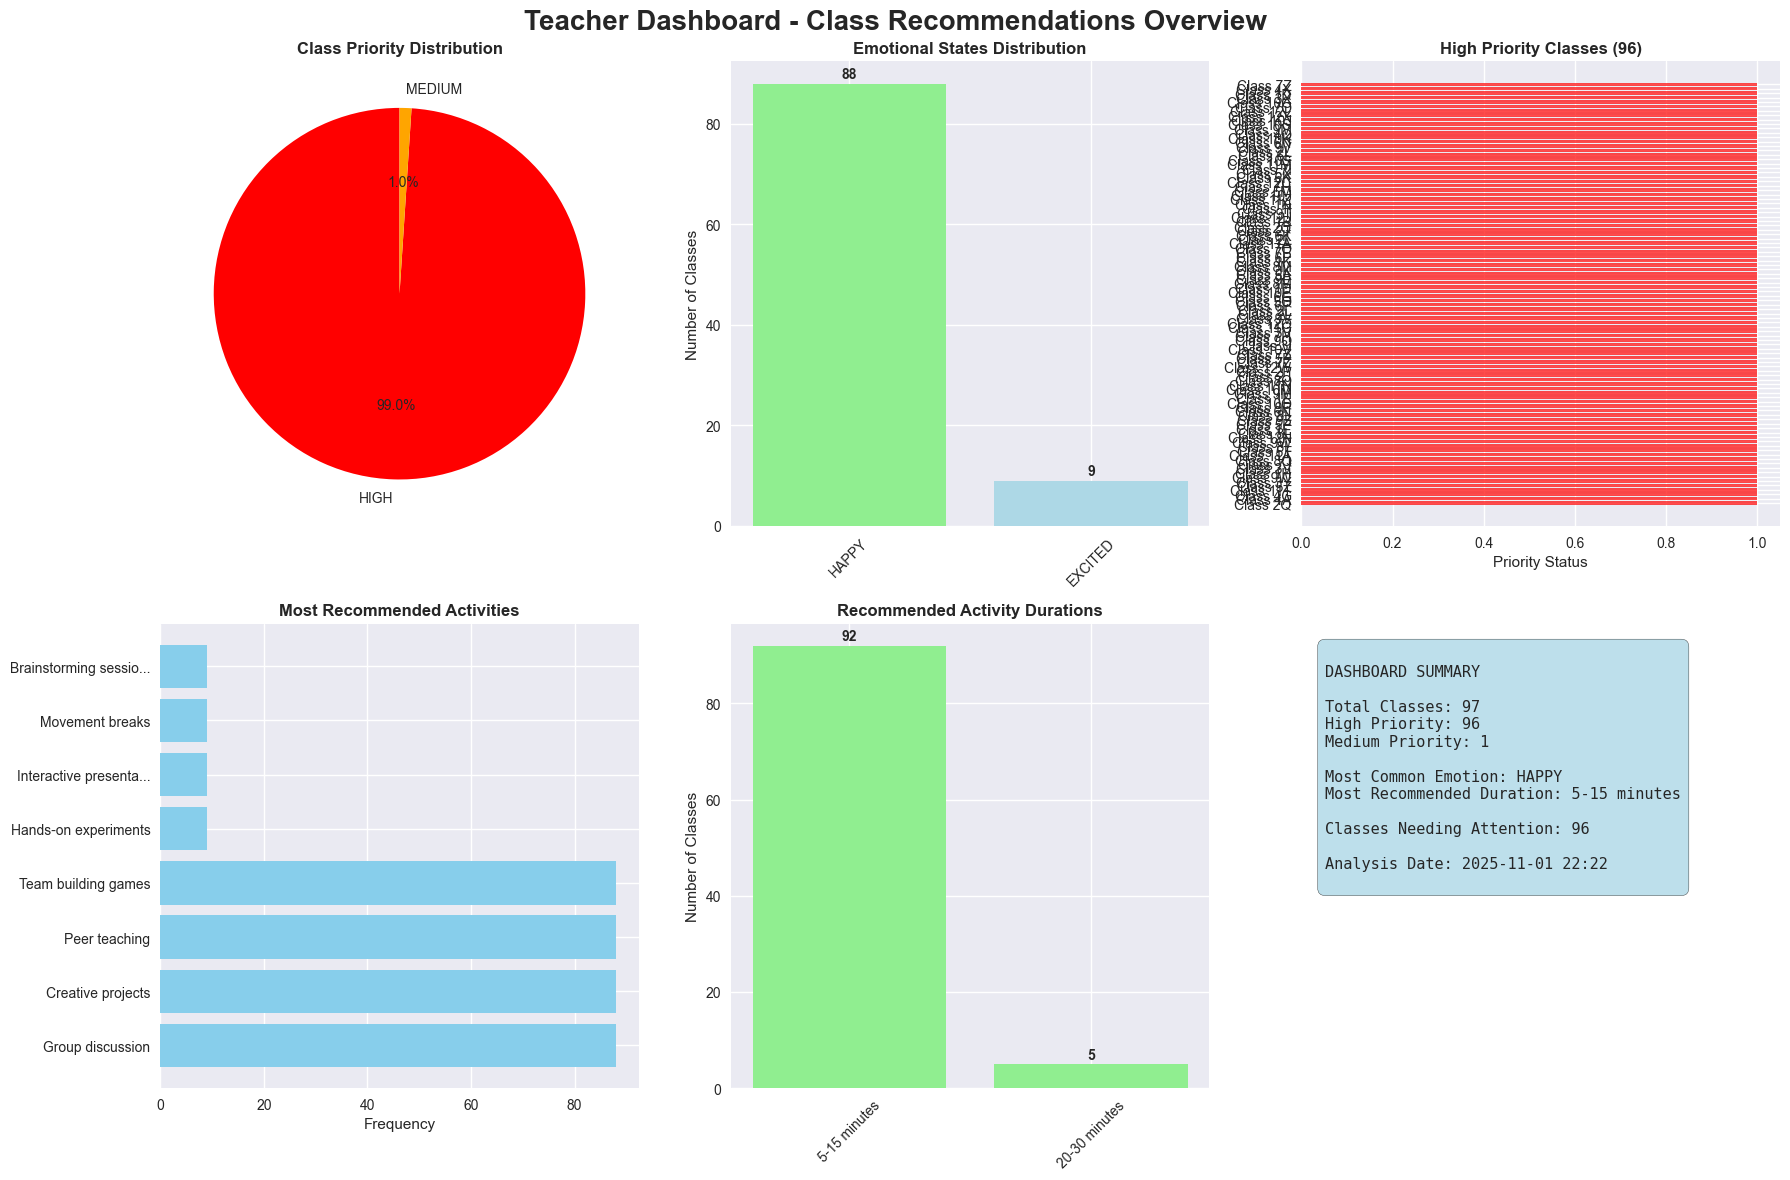


TOP 10 CLASS RECOMMENDATIONS

1. Class 1H
   Priority: HIGH
   Emotional State: HAPPY
   Recommended Activities: Group discussion, Creative projects, Peer teaching
   Duration: 5-15 minutes
   Focus: Maintain positive energy and encourage collaboration
   Considerations: Emotional trend is declining - monitor closely and provide extra support

2. Class 7J
   Priority: HIGH
   Emotional State: HAPPY
   Recommended Activities: Group discussion, Creative projects, Peer teaching
   Duration: 5-15 minutes
   Focus: Maintain positive energy and encourage collaboration
   Considerations: Emotional trend is declining - monitor closely and provide extra support

3. Class 5T
   Priority: HIGH
   Emotional State: HAPPY
   Recommended Activities: Group discussion, Creative projects, Peer teaching
   Duration: 5-15 minutes
   Focus: Maintain positive energy and encourage collaboration
   Considerations: Emotional trend is declining - monitor closely and provide extra support

4. Class 8L
   Priori

In [8]:
# Create comprehensive teacher dashboard with visualizations
print("Creating teacher dashboard...")

# Create dashboard visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Teacher Dashboard - Class Recommendations Overview', fontsize=20, fontweight='bold', y=0.98)

# 1. Priority level distribution
ax1 = axes[0, 0]
priority_counts = pd.Series([r['priority_level'] for r in class_recommendations.values()]).value_counts()
colors = ['red', 'orange', 'green']
wedges, texts, autotexts = ax1.pie(priority_counts.values, labels=priority_counts.index, autopct='%1.1f%%', 
                                   colors=colors[:len(priority_counts)], startangle=90)
ax1.set_title('Class Priority Distribution', fontweight='bold', fontsize=12)

# 2. Emotional states distribution
ax2 = axes[0, 1]
emotion_counts = pd.Series([r['emotional_state'] for r in class_recommendations.values()]).value_counts()
bars = ax2.bar(emotion_counts.index, emotion_counts.values, color=['lightgreen', 'lightblue', 'lightcoral', 'lightyellow', 'lightpink', 'lightgray'])
ax2.set_title('Emotional States Distribution', fontweight='bold', fontsize=12)
ax2.set_ylabel('Number of Classes')
ax2.tick_params(axis='x', rotation=45)
for bar, count in zip(bars, emotion_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(count), 
             ha='center', va='bottom', fontweight='bold')

# 3. High priority classes by name
ax3 = axes[0, 2]
high_priority_classes = [r['class_name'] for r in class_recommendations.values() if r['priority_level'] == 'HIGH']
if high_priority_classes:
    bars = ax3.barh(range(len(high_priority_classes)), [1]*len(high_priority_classes), color='red', alpha=0.7)
    ax3.set_yticks(range(len(high_priority_classes)))
    ax3.set_yticklabels([name[:25] + '...' if len(name) > 25 else name for name in high_priority_classes])
    ax3.set_title(f'High Priority Classes ({len(high_priority_classes)})', fontweight='bold', fontsize=12)
    ax3.set_xlabel('Priority Status')
else:
    ax3.text(0.5, 0.5, 'No High Priority Classes', ha='center', va='center', transform=ax3.transAxes, fontsize=14)
    ax3.set_title('High Priority Classes', fontweight='bold', fontsize=12)

# 4. Activity recommendations frequency
ax4 = axes[1, 0]
all_activities = []
for rec in class_recommendations.values():
    all_activities.extend(rec['recommended_activities'])
activity_counts = pd.Series(all_activities).value_counts().head(10)
bars = ax4.barh(range(len(activity_counts)), activity_counts.values, color='skyblue')
ax4.set_yticks(range(len(activity_counts)))
ax4.set_yticklabels([act[:20] + '...' if len(act) > 20 else act for act in activity_counts.index])
ax4.set_title('Most Recommended Activities', fontweight='bold', fontsize=12)
ax4.set_xlabel('Frequency')

# 5. Duration recommendations
ax5 = axes[1, 1]
duration_counts = pd.Series([r['recommended_duration'] for r in class_recommendations.values()]).value_counts()
bars = ax5.bar(duration_counts.index, duration_counts.values, color='lightgreen')
ax5.set_title('Recommended Activity Durations', fontweight='bold', fontsize=12)
ax5.set_ylabel('Number of Classes')
ax5.tick_params(axis='x', rotation=45)
for bar, count in zip(bars, duration_counts.values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(count), 
             ha='center', va='bottom', fontweight='bold')

# 6. Summary statistics
ax6 = axes[1, 2]
ax6.axis('off')
summary_stats = f"""
DASHBOARD SUMMARY

Total Classes: {len(class_recommendations)}
High Priority: {len([r for r in class_recommendations.values() if r['priority_level'] == 'HIGH'])}
Medium Priority: {len([r for r in class_recommendations.values() if r['priority_level'] == 'MEDIUM'])}

Most Common Emotion: {pd.Series([r['emotional_state'] for r in class_recommendations.values()]).mode().iloc[0]}
Most Recommended Duration: {pd.Series([r['recommended_duration'] for r in class_recommendations.values()]).mode().iloc[0]}

Classes Needing Attention: {len(high_priority_classes)}

Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}
"""
ax6.text(0.05, 0.95, summary_stats, transform=ax6.transAxes, fontsize=11, 
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))

plt.tight_layout()
plt.show()

# Display top 10 class recommendations
print("\n" + "="*80)
print("TOP 10 CLASS RECOMMENDATIONS")
print("="*80)

top_recommendations = sorted(class_recommendations.values(), 
                           key=lambda x: (x['priority_level'] == 'HIGH', len(x['additional_considerations'])), 
                           reverse=True)[:10]

for i, rec in enumerate(top_recommendations, 1):
    print(f"\n{i}. {rec['class_name']}")
    print(f"   Priority: {rec['priority_level']}")
    print(f"   Emotional State: {rec['emotional_state']}")
    print(f"   Recommended Activities: {', '.join(rec['recommended_activities'][:3])}")
    print(f"   Duration: {rec['recommended_duration']}")
    print(f"   Focus: {rec['activity_focus']}")
    if rec['additional_considerations']:
        print(f"   Considerations: {'; '.join(rec['additional_considerations'])}")

print("\n" + "="*80)
print("TEACHER DASHBOARD COMPLETED SUCCESSFULLY")
print("="*80)


## Save Results and Export Data


In [ ]:
# Save all results to files for future use
print("Saving analysis results...")

# Save class profiles to JSON
profiles_output = {
    "analysis_metadata": {
        "analysis_date": datetime.now().isoformat(),
        "total_classes_analyzed": len(class_profiles),
        "data_source": "studentCheckIn_cleaned.csv",
        "analysis_type": "class_based_emotional_profiling"
    },
    "class_profiles": class_profiles
}

with open('class_emotional_profiles.json', 'w', encoding='utf-8') as f:
    json.dump(profiles_output, f, indent=2, ensure_ascii=False, default=str)

print(f"Class profiles saved to: class_emotional_profiles.json")

# Save recommendations to JSON (fixed: removed undefined teacher_dashboard variable)
recommendations_output = {
    "analysis_metadata": {
        "analysis_date": datetime.now().isoformat(),
        "total_recommendations": len(class_recommendations),
        "high_priority_count": len([r for r in class_recommendations.values() if r['priority_level'] == 'HIGH']),
        "most_common_emotion": pd.Series([r['emotional_state'] for r in class_recommendations.values()]).mode().iloc[0]
    },
    "class_recommendations": class_recommendations
}

with open('class_recommendations.json', 'w', encoding='utf-8') as f:
    json.dump(recommendations_output, f, indent=2, ensure_ascii=False, default=str)

print(f"Class recommendations saved to: class_recommendations.json")

# Create summary CSV for easy viewing
summary_data = []
for class_id, profile in class_profiles.items():
    rec = class_recommendations.get(class_id, {})
    summary_data.append({
        'class_id': profile['class_id'],
        'class_name': profile['class_name'],
        'total_sessions': profile['total_sessions'],
        'total_students': profile['total_students'],
        'dominant_emotion': profile['emotions']['dominant_emotion'],
        'avg_intensity': profile['emotions']['avg_intensity'],
        'avg_tiredness': profile['wellness_indicators']['avg_tiredness'],
        'absence_rate': profile['wellness_indicators']['absence_rate'],
        'trend': profile['trend_analysis']['trend'],
        'priority_level': rec.get('priority_level', 'UNKNOWN'),
        'recommended_activities': '; '.join(rec.get('recommended_activities', [])),
        'recommended_duration': rec.get('recommended_duration', 'N/A'),
        'last_session': profile['last_session']
    })

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('class_analysis_summary.csv', index=False)
print(f"Summary CSV saved to: class_analysis_summary.csv")

print("\n" + "="*60)
print("ANALYSIS COMPLETION SUMMARY")
print("="*60)
print(f"Total classes analyzed: {len(class_profiles)}")
print(f"High priority classes: {len([r for r in class_recommendations.values() if r['priority_level'] == 'HIGH'])}")
print(f"Medium priority classes: {len([r for r in class_recommendations.values() if r['priority_level'] == 'MEDIUM'])}")
print(f"Most common emotion: {pd.Series([r['emotional_state'] for r in class_recommendations.values()]).mode().iloc[0]}")
print(f"Analysis date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("\nFiles created:")
print("- class_emotional_profiles.json (detailed class profiles)")
print("- class_recommendations.json (teacher recommendations)")
print("- class_analysis_summary.csv (summary table)")
print("="*60)
print("ANALYSIS COMPLETED SUCCESSFULLY")
print("="*60)
